# Figure 2b-c: Phenotype distributions and pairwise correlations
This notebook generates panels for Figure 1 of the Omi32 antibody library analysis.
- **Figure 2b**: Boxplots of each predicted phenotype (BA.1, BA.4, Wuhan affinity, expression, polyspecificity) as a function of the number of mutations, with marginal histograms marking germline and Omi-32 reference values.
- **Figure 2c**: Pairwise scatter plots of BA.1 affinity vs. each other phenotype, plus expression vs. polyspecificity, colored by mutation count with ODR regression lines and Pearson r.

All phenotype values are epistasis model predictions for the full 8192-variant combinatorial library.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FixedLocator
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patches
import seaborn as sns
from scipy.stats import pearsonr
from scipy import odr
import os

os.makedirs('Figure_2b', exist_ok=True)
os.makedirs('Figure_2c', exist_ok=True)

# Set Arial font globally
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.bf'] = 'Arial:bold'
plt.rcParams['axes.linewidth'] = 0.25

In [2]:
# Load epistasis model predictions for each phenotype
ba1 = pd.read_csv('../../epistasis_inference/linear_interaction_models/ba1/reference-based/predicted_phenotypes/ba1_raw_3order_full_biochem_predictions.csv').rename(columns={'predicted_phenotype': 'log10Kd'})
ba1['geno'] = ba1['geno'].astype('string').str.zfill(13)

ba4 = pd.read_csv('../../epistasis_inference/linear_interaction_models/ba4/reference-based/predicted_phenotypes/ba4_raw_3order_full_biochem_predictions.csv').rename(columns={'predicted_phenotype': 'log10Kd'})
ba4['geno'] = ba4['geno'].astype('string').str.zfill(13)

wuhan = pd.read_csv('../../epistasis_inference/linear_interaction_models/wuhan/reference-based/predicted_phenotypes/wuhan_raw_2order_full_biochem_predictions.csv').rename(columns={'predicted_phenotype': 'log10Kd'})
wuhan['geno'] = wuhan['geno'].astype('string').str.zfill(13)

psr = pd.read_csv('../../epistasis_inference/linear_interaction_models/psr/reference-based/predicted_phenotypes/psr_raw_2order_full_biochem_predictions.csv').rename(columns={'predicted_phenotype': 'log10Kd'})
psr['geno'] = psr['geno'].astype('string').str.zfill(13)
psr = psr[['geno', 'log10Kd']]

expr = pd.read_csv('../../epistasis_inference/linear_interaction_models/expression/reference-based/predicted_phenotypes/expression_raw_2order_full_biochem_predictions.csv').rename(columns={'predicted_phenotype': 'expr_mednorm_mean'})
expr['geno'] = expr['geno'].astype('string').str.zfill(13)
expr = expr[['geno', 'expr_mednorm_mean']]

# Merge all phenotypes into a single dataframe
df = pd.merge(ba4.rename(columns={'log10Kd': 'ba4_log10Kd_mean'}), ba1.rename(columns={'log10Kd': 'ba1_log10Kd_mean'}), on='geno', how='outer')
df = df.merge(wuhan.rename(columns={'log10Kd': 'wuhan_log10Kd_mean'}), on='geno', how='outer')
df = df.merge(psr.rename(columns={'log10Kd': 'psr_EC50'}), on='geno', how='outer')
df = df.merge(expr, on='geno', how='outer')
df = df.rename(columns={'expr_mednorm_mean': 'log_expr'})
df['geno'] = df['geno'].astype('string').str.zfill(13)


# Count mutations per genotype
df['num_muts'] = df['geno'].apply(lambda g: g.count('1'))

# Compute delta expression relative to germline
germline_geno = '0000000000000'
germline_expr_val = df.loc[df['geno'] == germline_geno, 'log_expr'].values[0]
df['delta_log_expr'] = df['log_expr'] - germline_expr_val

# Coerce numeric columns
num_cols = ['wuhan_log10Kd_mean', 'ba1_log10Kd_mean', 'ba4_log10Kd_mean', 'log_expr', 'psr_EC50', 'num_muts']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

## Figure 2b: Phenotype distributions by mutation count
Boxplots showing each phenotype as a function of the number of mutations from germline. Marginal histograms on the right show the overall distribution, with horizontal lines marking the germline (dark) and Omi-32 (light) reference values.

/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_3134/2801935686.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num_muts', y=col, data=df_plot, palette='viridis',


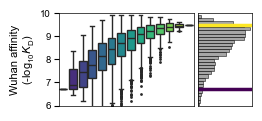

/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_3134/2801935686.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num_muts', y=col, data=df_plot, palette='viridis',


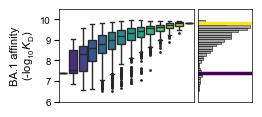

/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_3134/2801935686.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num_muts', y=col, data=df_plot, palette='viridis',


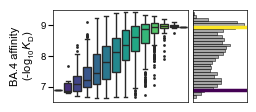

/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_3134/2801935686.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num_muts', y=col, data=df_plot, palette='viridis',


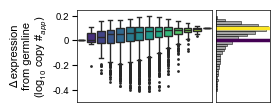

/var/folders/5c/ryv595916w771v24ng_5_tzw0000gn/T/ipykernel_3134/2801935686.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='num_muts', y=col, data=df_plot, palette='viridis',


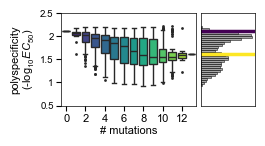

In [3]:
# Reference genotypes
germline_geno = '0000000000000'
omi32_geno = '1111111111111'
omi32_color = '#FDE725'
germline_color = '#440154'

flierprops = dict(marker='o', markersize=1, linestyle='none')

# Phenotype definitions: (column, ylabel, title, tag, ylim, yticks)
measurements = [
    ('wuhan_log10Kd_mean', 'Wuhan affinity\n(-log$_{10}$$K_{\\mathrm{D}}$)', 'Wuhan', 'wuhan', (6, 10), np.arange(6, 11, 1)),
    ('ba1_log10Kd_mean',   'BA.1 affinity\n(-log$_{10}$$K_{\\mathrm{D}}$)',  'BA.1', 'ba1', (6, 10.5), np.arange(6, 11, 1)),
    ('ba4_log10Kd_mean',   'BA.4 affinity\n(-log$_{10}$$K_{\\mathrm{D}}$)',  'BA.4', 'ba4', (6.5, 9.5), np.arange(7, 10, 1)),
    ('delta_log_expr',     'Δ expression\nfrom germline\n(log$_{10}$ copy #$_{\mathit{app}}$)', 'Expression', 'expr', (-0.5, 0.25), np.arange(-0.4, 0.3, 0.2)),
    ('psr_EC50',           'polyspecificity\n(-log$_{10}$$EC_{\\mathrm{50}}$)', 'polyspecificity', 'psr', (0.5, 2.5), np.arange(0.5, 3.0, 0.5)),
]

for col, y_label, title, tag, y_range, y_ticks in measurements:
    df_plot = df.dropna(subset=[col, 'num_muts']).copy()
    if df_plot.empty:
        continue

    germline_val = df_plot.loc[df_plot['geno'] == germline_geno, col].values
    omi32_val = df_plot.loc[df_plot['geno'] == omi32_geno, col].values
    germline_val = germline_val[0] if len(germline_val) > 0 else None
    omi32_val = omi32_val[0] if len(omi32_val) > 0 else None

    fig = plt.figure(figsize=(2.5, 1.2))
    gs = fig.add_gridspec(1, 2, width_ratios=[2.5, 1], wspace=0.05)
    ax_box = fig.add_subplot(gs[0])
    ax_hist = fig.add_subplot(gs[1], sharey=ax_box)

    # Boxplot
    sns.boxplot(x='num_muts', y=col, data=df_plot, palette='viridis',
                saturation=1, flierprops=flierprops, linewidth=1, ax=ax_box)

    # Only show x-axis label on the bottom panel (PSR)
    if tag == 'psr':
        ax_box.set_xlabel('# mutations', fontsize=8, labelpad=2)
        ax_box.tick_params(axis='x', bottom=True, labelbottom=True, labelsize=8, pad=2)
    else:
        ax_box.set_xlabel('')
        ax_box.tick_params(axis='x', bottom=False, labelbottom=False)

    ax_box.set_ylabel(y_label, fontsize=8, labelpad=2)

    x_max = int(df_plot['num_muts'].max())
    x_ticks_box = np.arange(0, x_max + 1, 2 if x_max > 6 else 1)
    ax_box.xaxis.set_major_locator(FixedLocator(x_ticks_box))
    ax_box.set_xticklabels([str(int(x)) for x in x_ticks_box])

    ax_box.set_ylim(y_range)
    ax_box.yaxis.set_major_locator(FixedLocator(y_ticks))
    ax_box.set_yticklabels([f'{yt:g}' for yt in y_ticks])
    ax_box.tick_params(axis='y', labelsize=7, pad=2)

    # Marginal histogram
    ax_hist.hist(df_plot[col], bins=30, orientation='horizontal', color='gray',
                 alpha=0.7, edgecolor='black', linewidth=0.5)

    if germline_val is not None:
        ax_hist.axhline(y=germline_val, color=germline_color, linewidth=2.5)
    if omi32_val is not None:
        ax_hist.axhline(y=omi32_val, color=omi32_color, linewidth=2.5)

    ax_hist.tick_params(axis='x', bottom=False, labelbottom=False)
    ax_hist.tick_params(axis='y', left=False, right=False, labelleft=False)

    for spine in ax_hist.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)
    for spine in ax_box.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)

    plt.savefig(f'Figure_2b/box_num_muts_{tag}_Figure_2b.png', transparent=True, bbox_inches='tight', dpi=2000)
    plt.show()

In [4]:
# Summary statistics for text
germline_geno = '0000000000000'

print('Fraction of variants with lower expression than germline:',
      len(df.loc[df['delta_log_expr'] < 0]) / len(df))

psr_germline = df.loc[df['geno'] == germline_geno, 'psr_EC50'].values[0]
print('Germline PSR value:', psr_germline)
print('Fraction of variants with higher PSR than germline:',
      len(df.loc[df['psr_EC50'] > psr_germline]) / len(df))

germline_ba4 = df.loc[df['geno'] == germline_geno, 'ba4_log10Kd_mean'].values[0]
germline_ba1 = df.loc[df['geno'] == germline_geno, 'ba1_log10Kd_mean'].values[0]
germline_wuhan = df.loc[df['geno'] == germline_geno, 'wuhan_log10Kd_mean'].values[0]
print('Germline BA.4:', germline_ba4)
print('Germline BA.1:', germline_ba1)
print('Germline Wuhan:', germline_wuhan)

print()
print('Fraction with higher BA.1 affinity but lower BA.4 affinity than germline:',
      len(df.loc[(df['ba1_log10Kd_mean'] > germline_ba1) & (df['ba4_log10Kd_mean'] <= germline_ba4)]) / len(df))
print('Fraction with higher BA.1 affinity but lower Wuhan affinity than germline:',
      len(df.loc[(df['ba1_log10Kd_mean'] > germline_ba1) & (df['wuhan_log10Kd_mean'] <= germline_wuhan)]) / len(df))
print('Fraction with higher BA.1 affinity but lower expression than germline:',
      len(df.loc[(df['ba1_log10Kd_mean'] > germline_ba1) & (df['delta_log_expr'] <= 0)]) / len(df))
print('Fraction with higher BA.1 affinity but higher PSR than germline:',
      len(df.loc[(df['ba1_log10Kd_mean'] > germline_ba1) & (df['psr_EC50'] >= psr_germline)]) / len(df))

print()
print('Fraction with higher BA.4 affinity but lower BA.1 affinity than germline:',
      len(df.loc[(df['ba4_log10Kd_mean'] > germline_ba4) & (df['ba1_log10Kd_mean'] <= germline_ba1)]) / len(df))
print('Fraction with higher Wuhan affinity but lower BA.1 affinity than germline:',
      len(df.loc[(df['wuhan_log10Kd_mean'] > germline_wuhan) & (df['ba1_log10Kd_mean'] <= germline_ba1)]) / len(df))
print('Fraction with higher expression but lower BA.1 affinity than germline:',
      len(df.loc[(df['delta_log_expr'] > 0) & (df['ba1_log10Kd_mean'] <= germline_ba1)]) / len(df))
print('Fraction with lower PSR but lower BA.1 affinity than germline:',
      len(df.loc[(df['psr_EC50'] < psr_germline) & (df['ba1_log10Kd_mean'] <= germline_ba1)]) / len(df))

print()
print('Fraction with higher BA.1 and BA.4 affinity than germline:',
      len(df.loc[(df['ba1_log10Kd_mean'] > germline_ba1) & (df['ba4_log10Kd_mean'] > germline_ba4)]) / len(df))
print('Fraction with higher BA.1 and Wuhan affinity than germline:',
      len(df.loc[(df['ba1_log10Kd_mean'] > germline_ba1) & (df['wuhan_log10Kd_mean'] > germline_wuhan)]) / len(df))
print('Fraction with higher BA.1 affinity and higher expression than germline:',
      len(df.loc[(df['ba1_log10Kd_mean'] > germline_ba1) & (df['delta_log_expr'] > 0)]) / len(df))
print('Fraction with higher BA.1 affinity and lower PSR than germline:',
      len(df.loc[(df['ba1_log10Kd_mean'] > germline_ba1) & (df['psr_EC50'] < psr_germline)]) / len(df))
print('Fraction with higher BA.1 affinity and higher PSR than germline:',
      len(df.loc[(df['ba1_log10Kd_mean'] > germline_ba1) & (df['psr_EC50'] >= psr_germline)]) / len(df))

print('Fraction with lower PSR and lower expression than germline:',
      len(df.loc[(df['psr_EC50'] < psr_germline) & (df['delta_log_expr'] <= 0)]) / len(df))
print('Fraction with higher PSR and higher expression than germline:',
      len(df.loc[(df['psr_EC50'] >= psr_germline) & (df['delta_log_expr'] > 0)]) / len(df))

Fraction of variants with lower expression than germline: 0.228515625
Germline PSR value: 2.122274186835201
Fraction of variants with higher PSR than germline: 0.0262451171875
Germline BA.4: 6.874338613450884
Germline BA.1: 7.398105259990238
Germline Wuhan: 6.709208060205642

Fraction with higher BA.1 affinity but lower BA.4 affinity than germline: 0.013916015625
Fraction with higher BA.1 affinity but lower Wuhan affinity than germline: 0.0125732421875
Fraction with higher BA.1 affinity but lower expression than germline: 0.2266845703125
Fraction with higher BA.1 affinity but higher PSR than germline: 0.023193359375

Fraction with higher BA.4 affinity but lower BA.1 affinity than germline: 0.021728515625
Fraction with higher Wuhan affinity but lower BA.1 affinity than germline: 0.0233154296875
Fraction with higher expression but lower BA.1 affinity than germline: 0.030029296875
Fraction with lower PSR but lower BA.1 affinity than germline: 0.02880859375

Fraction with higher BA.1 and B

## Figure 2c: Pairwise phenotype correlations
Scatter plots comparing BA.1 affinity against each other phenotype, plus expression vs. polyspecificity. Points are colored by mutation count. Dashed lines show ODR (orthogonal distance regression) fits; solid lines show 1:1 identity for affinity-affinity comparisons. Germline and Omi-32 are marked with stars.

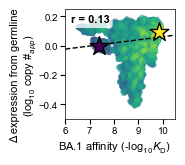

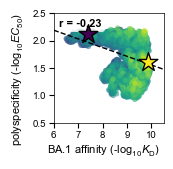

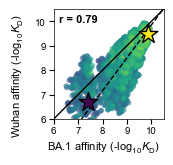

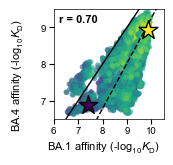

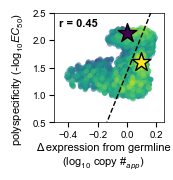

In [5]:
# Axis configuration for each phenotype
axis_config = {
    'wuhan_log10Kd_mean': {'range': (6, 10.5), 'ticks': [6, 7, 8, 9, 10]},
    'ba1_log10Kd_mean':   {'range': (6, 10.5), 'ticks': [6, 7, 8, 9, 10]},
    'ba4_log10Kd_mean':   {'range': (6.5, 9.5), 'ticks': [7, 8, 9]},
    'delta_log_expr':     {'range': (-0.5, 0.25), 'ticks': [-0.4, -0.2, 0, 0.2]},
    'psr_EC50':           {'range': (0.5, 2.5), 'ticks': [0.5, 1.0, 1.5, 2.0, 2.5]},
}

# Reference genotypes
germline_geno = '0000000000000'
omi32_geno = '1111111111111'

# ODR (total least squares) regression
def fit_tls_odr(x, y):
    def f(beta, x_):
        return beta[0] * x_ + beta[1]
    model = odr.Model(f)
    data = odr.RealData(np.asarray(x, dtype=float), np.asarray(y, dtype=float))
    out = odr.ODR(data, model, beta0=[1.0, 0.0]).run()
    return out.beta[0], out.beta[1]

def make_scatter(x_col, y_col, x_label, y_label, filename_suffix,
                 is_affinity_comparison=False):

    df_plot = df.dropna(subset=[x_col, y_col, 'num_muts']).copy()
    df_plot['geno'] = df_plot['geno'].astype(str).str.zfill(13)
    if df_plot.empty:
        return

    x = df_plot[x_col].to_numpy()
    y = df_plot[y_col].to_numpy()
    c = df_plot['num_muts'].to_numpy()

    # Pearson r and ODR fit
    r, _ = pearsonr(x, y) if len(x) > 1 else (np.nan, np.nan)
    try:
        m, b = fit_tls_odr(x, y)
    except:
        m, b = np.nan, np.nan

    x_min, x_max = axis_config[x_col]['range']
    y_min, y_max = axis_config[y_col]['range']

    fig, ax = plt.subplots(figsize=(1.75, 1.75))

    norm = Normalize(vmin=c.min(), vmax=c.max())
    cmap = plt.cm.viridis

    # Regular variants
    mask_regular = ~df_plot['geno'].isin([germline_geno, omi32_geno])
    ax.scatter(x[mask_regular], y[mask_regular], c=c[mask_regular], cmap='viridis',
               s=15, alpha=0.6, edgecolors='none', norm=norm)

    # Germline and Omi-32 as stars colored by mutation count
    for ref_geno in [germline_geno, omi32_geno]:
        ref_data = df_plot[df_plot['geno'] == ref_geno]
        if not ref_data.empty:
            ref_color = cmap(norm(ref_data['num_muts'].values[0]))
            ax.scatter(ref_data[x_col].values, ref_data[y_col].values,
                       color=ref_color, s=200, marker='*',
                       edgecolors='black', linewidth=1, zorder=10)

    # ODR regression line (dashed)
    if not np.isnan(m):
        x_line = np.linspace(x_min, x_max, 100)
        ax.plot(x_line, m * x_line + b, color='black', linewidth=1, linestyle='--', zorder=5)

    # 1:1 identity line for affinity-affinity comparisons (solid)
    if is_affinity_comparison:
        diag_min = max(x_min, y_min)
        diag_max = min(x_max, y_max)
        ax.plot([diag_min, diag_max], [diag_min, diag_max],
                color='black', linewidth=1, linestyle='-', zorder=5)

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_xticks(axis_config[x_col]['ticks'])
    ax.set_yticks(axis_config[y_col]['ticks'])
    ax.set_xlabel(x_label, fontsize=8, labelpad=2)
    ax.set_ylabel(y_label, fontsize=8, labelpad=2)
    ax.xaxis.set_label_coords(0.45, -0.18)
    ax.yaxis.set_label_coords(-0.25, 0.4)
    ax.tick_params(labelsize=7, pad=2)

    # Pearson r annotation
    ax.text(0.05, 0.95, f'r = {r:.2f}', transform=ax.transAxes, va='top', ha='left',
            fontsize=8, fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='none'))

    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(0.5)

    fig_w, fig_h = fig.get_size_inches()
    plt.subplots_adjust(left=min(0.6 / fig_w, 0.6), right=0.97,
                        top=0.97, bottom=min(0.6 / fig_h, 0.6))

    plt.savefig(f'{filename_suffix}.png', dpi=2000, transparent=True)
    plt.show()

# BA.1 vs expression
make_scatter('ba1_log10Kd_mean', 'delta_log_expr',
             'BA.1 affinity (-log$_{10}$$K_{\\mathrm{D}}$)',
             'Δ expression from germline\n(log$_{10}$ copy #$_{\mathit{app}}$)',
             'Figure_2c/ba1_vs_expression_Figure_2c')

# BA.1 vs polyspecificity
make_scatter('ba1_log10Kd_mean', 'psr_EC50',
             'BA.1 affinity (-log$_{10}$$K_{\\mathrm{D}}$)',
             'polyspecificity (-log$_{10}$$EC_{\\mathrm{50}}$)',
             'Figure_2c/ba1_vs_psr_Figure_2c')

# BA.1 vs Wuhan
make_scatter('ba1_log10Kd_mean', 'wuhan_log10Kd_mean',
             'BA.1 affinity (-log$_{10}$$K_{\\mathrm{D}}$)',
             'Wuhan affinity (-log$_{10}$$K_{\\mathrm{D}}$)',
             'Figure_2c/ba1_vs_wuhan_Figure_2c', is_affinity_comparison=True)

# BA.1 vs BA.4
make_scatter('ba1_log10Kd_mean', 'ba4_log10Kd_mean',
             'BA.1 affinity (-log$_{10}$$K_{\\mathrm{D}}$)',
             'BA.4 affinity (-log$_{10}$$K_{\\mathrm{D}}$)',
             'Figure_2c/ba1_vs_ba4_Figure_2c', is_affinity_comparison=True)

# Expression vs polyspecificity
make_scatter('delta_log_expr', 'psr_EC50',
             'Δ expression from germline\n(log$_{10}$ copy #$_{\mathit{app}}$)',
             'polyspecificity (-log$_{10}$$EC_{\\mathrm{50}}$)',
             'Figure_2c/expression_vs_psr_Figure_2c')

In [6]:
# Standalone colorbars for figure assembly
c_min = df['num_muts'].min()
c_max = df['num_muts'].max()
norm = Normalize(vmin=c_min, vmax=c_max)
sm = ScalarMappable(cmap=plt.cm.viridis, norm=norm)
sm.set_array([])

# Vertical colorbar
fig, ax = plt.subplots(figsize=(0.281, 1.125))
ax.axis('off')
cbar = plt.colorbar(sm, ax=ax, fraction=1.0, aspect=10, orientation='vertical')
cbar.set_label('', fontsize=0)
cbar.set_ticks([])
cbar.outline.set_linewidth(0.5)
plt.savefig('Figure_2c/2D_colorbar_vertical_Figure_2c.png', dpi=2000, bbox_inches='tight', transparent=True)
plt.show()

# Horizontal colorbar
fig, ax = plt.subplots(figsize=(1.125, 0.281))
ax.axis('off')
cbar = plt.colorbar(sm, ax=ax, fraction=1.0, aspect=10, orientation='horizontal')
cbar.set_label('', fontsize=0)
cbar.set_ticks([])
cbar.outline.set_linewidth(0.5)
plt.savefig('Figure_2c/2D_colorbar_horizontal_Figure_2c.png', dpi=2000, bbox_inches='tight', transparent=True)
plt.show()